In [21]:
import os
from torch.utils.data import Subset
import torch
from torch.cuda.amp import autocast, GradScaler
import random
import numpy as np
from torchinfo import summary
import tensorflow as tf
import rasterio as rio
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.colors as mcolors
from torch.utils.data import Dataset, DataLoader
import torch
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio as rio
import torch
import torch.nn as nn
from transformers import SegformerForSemanticSegmentation
import torch.nn.functional as F
import torchvision
from torchview import draw_graph


In [22]:

try:
    import torch
    print("PyTorch is installed:", torch.__version__)
except ImportError:
    print("PyTorch is NOT installed.")

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    a = torch.randn(1024,1024, device="cuda"); b = torch.mm(a, a.t()); print("OK:", b.is_cuda, b.shape)



PyTorch is installed: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
OK: True torch.Size([1024, 1024])


In [ ]:
data_dir = Path('../CV_new/AI_design/lab5/Potsdam-GeoTif/Potsdam-GeoTif')


all_files = sorted([str(p) for p in data_dir.glob("*.tif")]) 
print(f"Found {len(all_files)} tiles in source.")


random.seed(42)
n = len(all_files)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
# 1) Train vs temp (70% / 30%)
train_files, temp_files = train_test_split(
    all_files, test_size=0.30, random_state=42, shuffle=True
)

# 2) Temp -> Val/Test (split 30% into 15%/15% => 50/50 of temp)
val_files, test_files = train_test_split(
    temp_files, test_size=0.50, random_state=42, shuffle=True
)

print(f"Train: {len(train_files)}  ({len(train_files)/len(all_files)*100:.1f}%)")
print(f"Val  : {len(val_files)}   ({len(val_files)/len(all_files)*100:.1f}%)")
print(f"Test : {len(test_files)}  ({len(test_files)/len(all_files)*100:.1f}%)")




# Photometric sub-pipeline that we will apply ONLY to RGB+IR
photo_tf = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.5),
    A.RandomGamma(gamma_limit=(90,110), p=0.3),
   # A.GaussNoise(var_limit=(1e-5, 5e-4), p=0.2)
   #A.GaussNoise(std_range=(0.003, 0.022), mean_range=(0.0, 0.0), p=0.2)
])

def apply_photo_on_rgbir(image: np.ndarray, noise_std_range=(1e-3, 5e-3), **kwargs) -> np.ndarray:
    rgbir = image[..., :4]
    dsm   = image[..., 4:]

    # photometric on RGB+IR
    rgbir = photo_tf(image=rgbir)["image"]

    # add gaussian noise on RGB+IR only
    std = np.random.uniform(*noise_std_range)
    noise = np.random.normal(loc=0.0, scale=std, size=rgbir.shape).astype(np.float32)
    rgbir = np.clip(rgbir + noise, 0.0, 1.0)

    return np.concatenate([rgbir, dsm], axis=-1)




class PotsdamTiffDataset(Dataset):
    def __init__(self, file_list, transform=None, normalize=True):
        self.files = list(file_list)
        self.transform = transform       
        self.normalize = normalize

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        p = self.files[idx]
        with rio.open(p) as src:
            arr = src.read()                      # (C,H,W)
            arr = np.transpose(arr, (1,2,0))      # (H,W,C)
            img  = arr[..., :5].astype(np.float32)  # [R,G,B,IR,DSM]
            mask = arr[..., 5].astype(np.int64)     # class ids

        # Normalize: RGB+IR -> [0,1]; DSM -> per-tile standardization + clipping
        if self.normalize:
            # RGB + IR
            img[..., :4] /= 255.0

            # DSM (channel 4): z-score then clip
            dsm = img[..., 4]
            m, s = dsm.mean(), dsm.std() + 1e-6
            dsm_std = (dsm - m) / s                 # <-- standardized
            img[..., 4] = np.clip(dsm_std, -5.0, 5.0)  # <-- clip standardized DSM

        # Apply your transform if provided
        if self.transform is not None:
            out = self.transform(image=img, mask=mask)
            img, mask = out["image"], out["mask"]

        # To tensors
        img  = torch.from_numpy(np.transpose(img, (2,0,1))).float()  # (5,H,W)
        mask = torch.from_numpy(mask).long()                          # (H,W)
        return img, mask


# Train: geometric (image+mask) + photometric (RGB+IR only)
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.5),

    # photometric only on RGB+IR via Lambda wrapper
    A.Lambda(image=apply_photo_on_rgbir, p=1.0),
])


val_transform = A.Compose([])

# Build datasets/loaders
batch_size_train = 4
batch_size_val   = 32

raw_dataset = PotsdamTiffDataset(train_files, transform=None, normalize=True) 


train_dataset = PotsdamTiffDataset(train_files, transform=train_transform, normalize=True)
val_dataset   = PotsdamTiffDataset(val_files,   transform=val_transform,   normalize=True)
test_dataset  = PotsdamTiffDataset(test_files,  transform=val_transform,   normalize=True)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))
train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size_val, shuffle=False,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size_val, shuffle=False,
                           pin_memory=True)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

Found 15048 tiles in source.
Train: 10533  (70.0%)
Val  : 2257   (15.0%)
Test : 2258  (15.0%)
10533
2257
2258
2633
71
71


In [ ]:
# trining loop
def per_class_iou(preds, labels, num_classes=6):
    """Batch-averaged mIoU (skip classes with zero union)."""
    ious = []
    for c in range(num_classes):
        inter = ((preds == c) & (labels == c)).sum().float()
        union = ((preds == c) | (labels == c)).sum().float()
        if union.item() == 0:
            continue
        ious.append(inter / union)
    return torch.stack(ious).mean().item() if ious else 0.0


def output_to_label(logits):
    """(B,C,H,W) -> (B,H,W) hard labels."""
    return torch.argmax(logits, dim=1)


def pixel_accuracy(preds, labels):
    """Mean pixel accuracy over a batch."""
    return (preds == labels).float().mean().item()


# validate
def validate(model, loss_fn, val_loader, device, num_classes=6):
    val_loss_cum, val_acc_cum = 0.0, 0.0

    # accumulators for dataset-level IoU on device (double for exactness)
    inters = torch.zeros(num_classes, dtype=torch.double, device=device)
    unions = torch.zeros(num_classes, dtype=torch.double, device=device)

    # confusion matrix 
    cm = torch.zeros((num_classes, num_classes), dtype=torch.long)

    model.eval()
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            val_loss_cum += loss_fn(logits, y).item()

            preds = torch.argmax(logits, dim=1)
            val_acc_cum += (preds == y).float().mean().item()

            # IoU accumulators
            for c in range(num_classes):
                inters[c] += (((preds == c) & (y == c)).sum()).double()
                unions[c] += (((preds == c) | (y == c)).sum()).double()

            # confusion matrix via bincount
            k = (y >= 0) & (y < num_classes)
            inds = (num_classes * y[k].to(torch.int64) + preds[k].to(torch.int64)).view(-1)
            cm += torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes).cpu()

    # per-class IoU + mIoU
    inters, unions = inters.cpu(), unions.cpu()
    per_class = [(inters[c] / unions[c]).item() if unions[c].item() > 0 else float('nan')
                 for c in range(num_classes)]
    valid = [v for v in per_class if not (v != v)]  # drop NaNs
    miou = (sum(valid) / len(valid)) if valid else 0.0

    n = len(val_loader)
    return (val_loss_cum / n), (val_acc_cum / n), miou, per_class, cm


# train one epoch
def train_epoch(model, optimizer, loss_fn, train_loader, val_loader, device, print_every, num_classes):
    model.train()
    train_loss_batches, train_acc_batches = [], []
    num_batches = len(train_loader)

    for batch_index, (x, y) in enumerate(train_loader, 1):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_batches.append(loss.item())
        preds = output_to_label(logits)
        train_acc_batches.append(pixel_accuracy(preds, y))

        if print_every is not None and batch_index % print_every == 0:
            v_loss, v_acc, v_miou, v_per_class, _ = validate(model, loss_fn, val_loader, device, num_classes)
            model.train()
            print(
                f"\tBatch {batch_index}/{num_batches}: "
                f"\tTrain loss: {sum(train_loss_batches[-print_every:])/print_every:.3f}, "
                f"\tTrain acc.: {sum(train_acc_batches[-print_every:])/print_every:.3f}, "
                f"\tVal. loss: {v_loss:.3f}, "
                f"\tVal. acc.: {v_acc:.3f}, "
                f"\tVal. mIoU: {v_miou:.3f}"
            )
            print("\tVal. per-class IoU:", [None if (v!=v) else round(v, 3) for v in v_per_class])

    return model, train_loss_batches, train_acc_batches


# top-level loop (now SAVES per-class IoU & CM per epoch)
def training_loop_with_iou_per_class(model, optimizer, loss_fn, train_loader, val_loader,
                                     num_epochs, print_every=None, num_classes=6):
    print("Starting training")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_losses, train_accs, val_losses, val_accs, val_mious = [], [], [], [], []
    val_per_class_history = []  # NEW: list of lists, shape (E, C)
    cm_history = []             # NEW: list of CxC tensors

    for epoch in range(1, num_epochs + 1):
        model, train_loss, train_acc = train_epoch(
            model, optimizer, loss_fn, train_loader, val_loader, device, print_every, num_classes
        )
        val_loss, val_acc, val_miou, val_per_class, cm = validate(
            model, loss_fn, val_loader, device, num_classes
        )

        print(
            f"Epoch {epoch}/{num_epochs}: "
            f"Train loss: {sum(train_loss)/len(train_loss):.3f}, "
            f"Train acc.: {sum(train_acc)/len(train_acc):.3f}, "
            f"Val. loss: {val_loss:.3f}, "
            f"Val. acc.: {val_acc:.3f}, "
            f"Val. mIoU: {val_miou:.3f}"
        )
        print("Val per-class IoU:", [None if (v!=v) else round(v, 3) for v in val_per_class])
        

        # save histories
        train_losses.extend(train_loss)
        train_accs.extend(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_mious.append(val_miou)
        val_per_class_history.append([float(v) for v in val_per_class])  # store a copy
        cm_history.append(cm.clone())  # store a copy

    # return the new histories too
    return (model, train_losses, train_accs, val_losses, val_accs,
            val_mious, val_per_class_history, cm_history)


# 5: deeplab fine tunning

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 6
IN_CHANNELS = 5



def build_deeplab5ch_finetune():
    base = deeplabv3_resnet50(
        weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1,
        aux_loss=True
    )

    # --- replace first conv to accept 5 channels
    old_conv = base.backbone.conv1
    new_conv = nn.Conv2d(IN_CHANNELS, old_conv.out_channels,
                         kernel_size=old_conv.kernel_size,
                         stride=old_conv.stride,
                         padding=old_conv.padding,
                         bias=False)
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        mean_rgb = old_conv.weight.mean(dim=1, keepdim=True)
        new_conv.weight[:, 3:4] = mean_rgb
        new_conv.weight[:, 4:5] = 0.0
    base.backbone.conv1 = new_conv

    # replace classifier and aux heads to 6 classes
    in_ch = base.classifier[-1].in_channels
    base.classifier[-1] = nn.Conv2d(in_ch, NUM_CLASSES, kernel_size=1)
    if base.aux_classifier is not None:
        aux_in = base.aux_classifier[-1].in_channels
        base.aux_classifier[-1] = nn.Conv2d(aux_in, NUM_CLASSES, kernel_size=1)

    # unfreeze everything
    for p in base.parameters():
        p.requires_grad = True

    # wrapper to return logits only
    class DeeplabWrapper(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x):
            return self.model(x)["out"]

    return DeeplabWrapper(base)



dl_tuned = build_deeplab5ch_finetune().to(device)

# load weights from frozen checkpoint
ckpt = torch.load("./deepLab_model.ckpt", map_location=device)

# fix key prefix: change "m." → "model."
state_dict = ckpt["model_state_dict"]
state_dict = {k.replace("m.", "model."): v for k, v in state_dict.items()}

missing, unexpected = dl_tuned.load_state_dict(state_dict, strict=False)
print("Loaded frozen model weights.")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)


# LOSS + OPTIMIZER

cw = torch.load("class_weights.ckpt", map_location="cpu")["class_weights"]
class_weights = cw.clone().detach().to(device, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(dl_tuned.parameters(), lr=3e-4, weight_decay=1e-4)

print(" Model ready for fine-tuning!\n")



# TRAIN

deeplab_finetuned, dl_tr_loss2, dl_tr_acc2, dl_val_loss2, dl_val_acc2, \
    dl_val_miou2, dl_per_class_hist2, dl_cm_hist2 = training_loop_with_iou_per_class(
        dl_tuned, optimizer, criterion,
        train_loader, val_loader,
        num_epochs=10, print_every=100, num_classes=NUM_CLASSES
    )


print(" DeepLabV3-R50 Fine-tuned Val mIoU by epoch:",
      [round(x, 4) for x in dl_val_miou2])


Loaded frozen model weights.
Missing keys: []
Unexpected keys: []
 Model ready for fine-tuning!

Starting training
	Batch 100/2633: 	Train loss: 1.479, 	Train acc.: 0.511, 	Val. loss: 1.081, 	Val. acc.: 0.605, 	Val. mIoU: 0.373
	Val. per-class IoU: [0.444, 0.59, 0.436, 0.422, 0.176, 0.171]
	Batch 200/2633: 	Train loss: 1.162, 	Train acc.: 0.534, 	Val. loss: 0.939, 	Val. acc.: 0.628, 	Val. mIoU: 0.400
	Val. per-class IoU: [0.569, 0.59, 0.381, 0.425, 0.192, 0.245]
	Batch 300/2633: 	Train loss: 1.150, 	Train acc.: 0.572, 	Val. loss: 0.927, 	Val. acc.: 0.670, 	Val. mIoU: 0.433
	Val. per-class IoU: [0.576, 0.626, 0.518, 0.459, 0.221, 0.2]
	Batch 400/2633: 	Train loss: 1.043, 	Train acc.: 0.599, 	Val. loss: 0.901, 	Val. acc.: 0.649, 	Val. mIoU: 0.440
	Val. per-class IoU: [0.504, 0.66, 0.443, 0.466, 0.319, 0.248]
	Batch 500/2633: 	Train loss: 1.064, 	Train acc.: 0.604, 	Val. loss: 1.315, 	Val. acc.: 0.544, 	Val. mIoU: 0.354
	Val. per-class IoU: [0.527, 0.375, 0.35, 0.47, 0.247, 0.156]
	Batch 

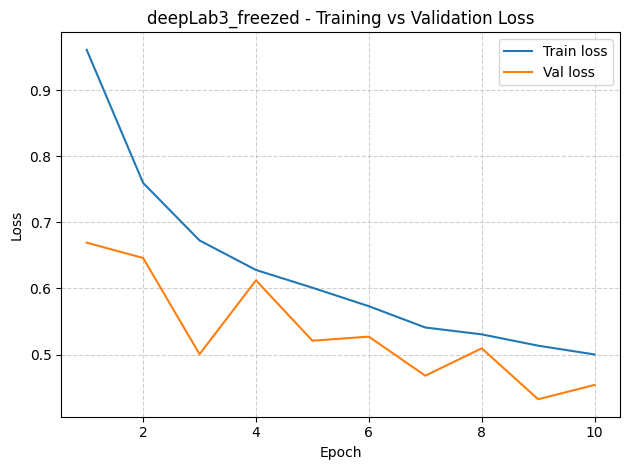

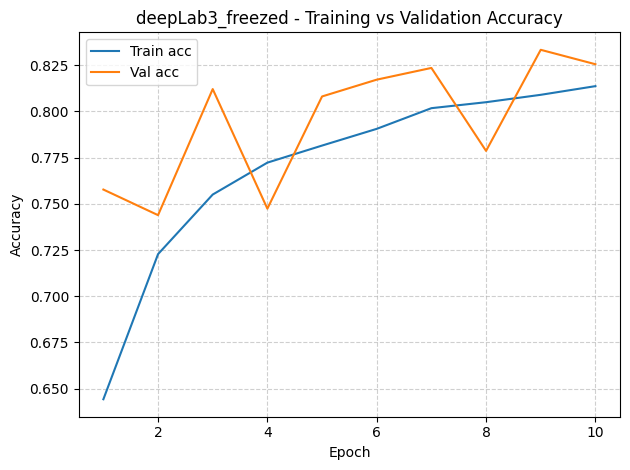

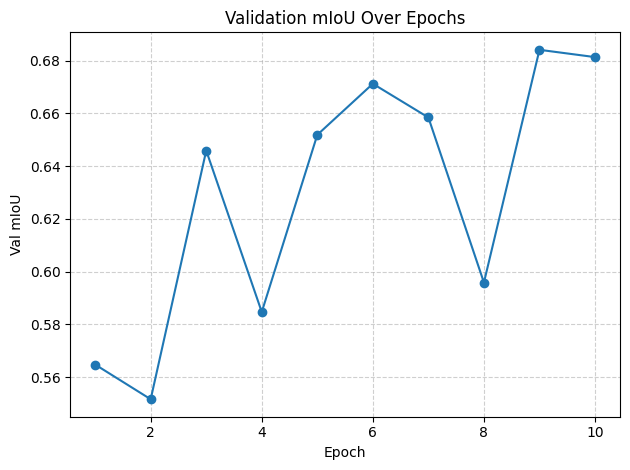

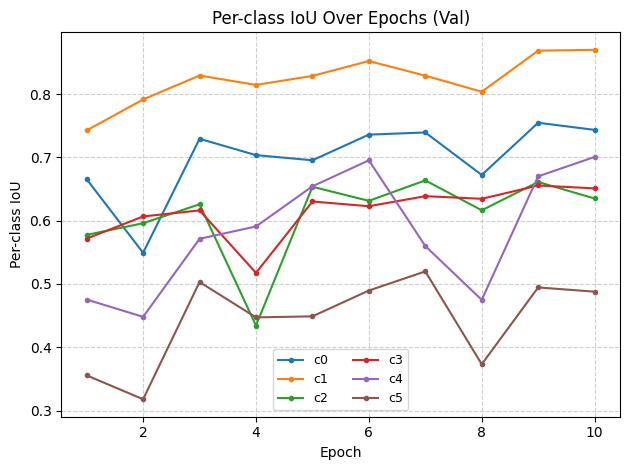

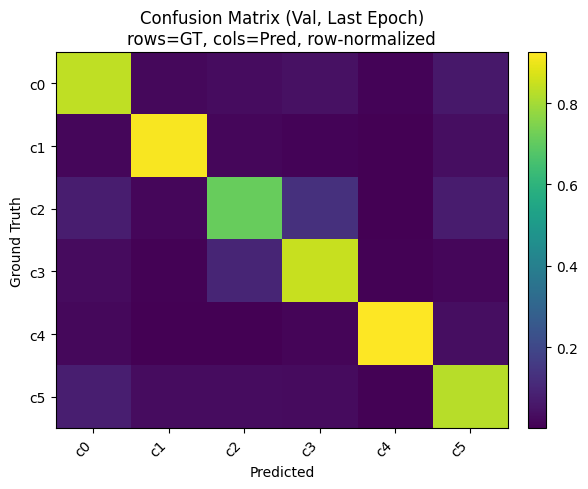

In [ ]:


def general_plot_curves(train_losses, train_accs, val_losses, val_accs, model_name="model"):
   
    n_epochs = len(val_losses)
    steps_per_epoch = len(train_losses) // n_epochs

    usable = steps_per_epoch * n_epochs
    train_loss_epoch = np.array(train_losses[:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)
    train_acc_epoch  = np.array(train_accs [:usable], dtype=float).reshape(n_epochs, steps_per_epoch).mean(axis=1)

    epochs = np.arange(1, n_epochs + 1)

    # Loss 
    plt.figure()
    plt.plot(epochs, train_loss_epoch, label="Train loss")
    plt.plot(epochs, val_losses, label="Val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{model_name} - Training vs Validation Loss")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(f"{model_name}_loss_curve.png")
    plt.show()

    # Accuracy 
    plt.figure()
    plt.plot(epochs, train_acc_epoch, label="Train acc")
    plt.plot(epochs, val_accs, label="Val acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Training vs Validation Accuracy")
    plt.legend(); plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(f"{model_name}_acc_curve.png")
    plt.show()
general_plot_curves(dl_tr_loss2, dl_tr_acc2, dl_val_loss2, dl_val_acc2, model_name="deepLab3_freezed")





def plot_key_metrics(w_val_miou, val_per_class_history, cm_history, class_names=None, prefix="weighted"):
    
    # w_val_miou:             list[float], length = epochs
    # val_per_class_history:  list[list[float or nan]], shape = (epochs, num_classes)
    # cm_history:             list[Tensor CxC], confusion matrix per epoch (rows=GT, cols=Pred)
    # class_names:            optional list[str] of length C
    # prefix:                 filename prefix for saved figures
    
    # 1) mIoU over epochs 
    epochs = np.arange(1, len(w_val_miou) + 1)
    plt.figure()
    plt.plot(epochs, w_val_miou, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Val mIoU")
    plt.title("Validation mIoU Over Epochs")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{prefix}_miou_curve.png", dpi=150)
    plt.show()

    #2) Per-class IoU over epochs
    per_class = np.array(val_per_class_history, dtype=float)  # (E, C) with possible NaNs
    num_classes = per_class.shape[1]
    if class_names is None:
        class_names = [f"c{i}" for i in range(num_classes)]

    plt.figure()
    for c in range(num_classes):
        plt.plot(epochs, per_class[:, c], marker=".", label=class_names[c])
    plt.xlabel("Epoch")
    plt.ylabel("Per-class IoU")
    plt.title("Per-class IoU Over Epochs (Val)")
    plt.legend(ncols=2, fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{prefix}_perclass_iou_curve.png", dpi=150)
    plt.show()

    # 3) Normalized confusion matrix 
    cm = cm_history[-1].cpu().numpy().astype(float)  # (C, C)
    row_sums = cm.sum(axis=1, keepdims=True) + 1e-9
    cm_norm = cm / row_sums

    plt.figure(figsize=(6,5))
    im = plt.imshow(cm_norm, interpolation="nearest", aspect="auto")
    plt.title("Confusion Matrix (Val, Last Epoch)\nrows=GT, cols=Pred, row-normalized")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_positions = np.arange(num_classes)
    plt.xticks(tick_positions, class_names, rotation=45, ha="right")
    plt.yticks(tick_positions, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.savefig(f"{prefix}_confusion_matrix_last_epoch.png", dpi=150)
    plt.show()


plot_key_metrics(
    dl_val_miou2,
    dl_per_class_hist2,
    dl_cm_hist2,
    class_names=None,      
    prefix="deepLab3_tuned"  
)

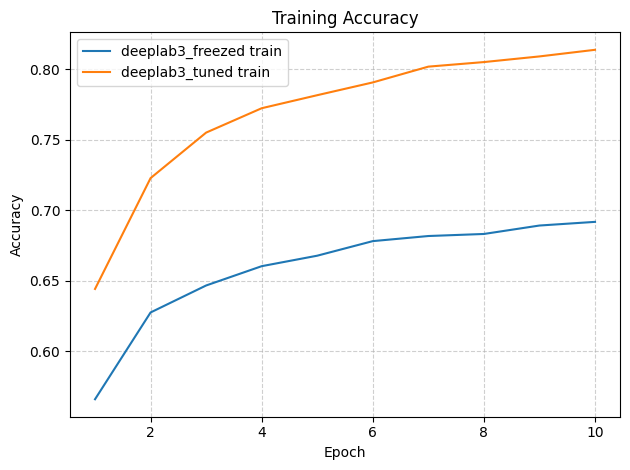

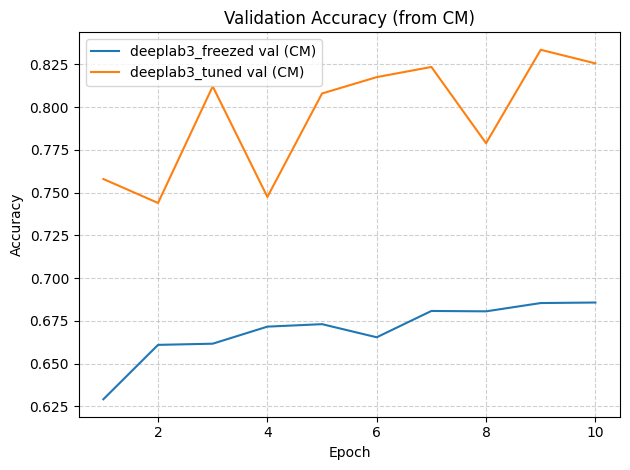

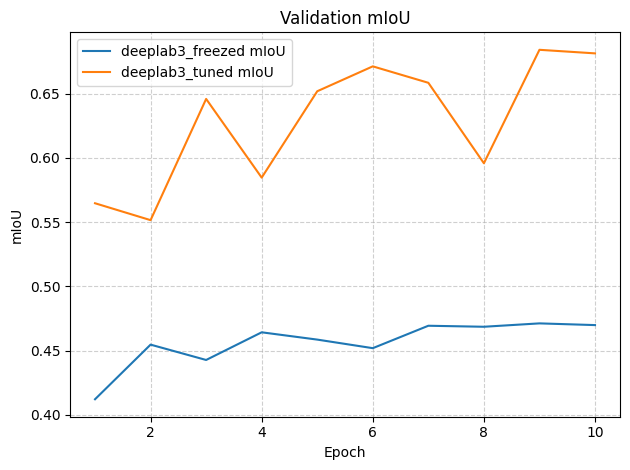

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import torch



def acc_from_cm_history(cm_history):
    
    # Compute dataset-true validation accuracy per epoch from confusion matrices.
    # Works for any batch_size_val.
    # cm_history: list of CxC tensors, rows=GT, cols=Pred.
    # Returns: list[float] of length epochs.
    
    accs = []
    for cm in cm_history:
        cm = cm.cpu().numpy()
        total = cm.sum()
        correct = np.trace(cm)
        accs.append(float(correct) / float(total) if total > 0 else 0.0)
    return accs

def avg_per_epoch(train_vals, n_epochs):
    #
    # Average per-batch training values into per-epoch values.
    # Assumes fixed steps per epoch (drop_last=True in train_loader makes this true).
    #
    steps = len(train_vals) // n_epochs
    if steps == 0:
        raise ValueError("Not enough training steps for the given number of epochs.")
    vals = np.array(train_vals[:steps * n_epochs], dtype=float).reshape(n_epochs, steps)
    return vals.mean(axis=1)

def compare_two_runs(train_accs_A, cm_history_A,
                     train_accs_B, cm_history_B,
                     name_A="Run A", name_B="Run B",
                     val_mious_A=None, val_mious_B=None):
    
    # Plot training accuracy (per epoch) and validation accuracy (from CM) for two runs.
    # Optionally also plot mIoU curves if provided.
    
    # CM-derived, batch-size-safe validation accuracy
    val_accs_A = acc_from_cm_history(cm_history_A)
    val_accs_B = acc_from_cm_history(cm_history_B)

    # Per-epoch train accuracy from per-batch logs
    train_ep_A = avg_per_epoch(train_accs_A, len(val_accs_A))
    train_ep_B = avg_per_epoch(train_accs_B, len(val_accs_B))

    # Training accuracy 
    plt.figure()
    plt.plot(np.arange(1, len(train_ep_A) + 1), train_ep_A, label=f"{name_A} train")
    plt.plot(np.arange(1, len(train_ep_B) + 1), train_ep_B, label=f"{name_B} train")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Training Accuracy")
    plt.grid(True, linestyle="--", alpha=0.6); plt.legend(); plt.tight_layout(); plt.show()

    #  Validation accuracy (from CM)
    minE = min(len(val_accs_A), len(val_accs_B))
    plt.figure()
    plt.plot(np.arange(1, minE + 1), val_accs_A[:minE], label=f"{name_A} val (CM)")
    plt.plot(np.arange(1, minE + 1), val_accs_B[:minE], label=f"{name_B} val (CM)")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Validation Accuracy (from CM)")
    plt.grid(True, linestyle="--", alpha=0.6); plt.legend(); plt.tight_layout(); plt.show()

    
    if val_mious_A is not None and val_mious_B is not None:
        mE = min(len(val_mious_A), len(val_mious_B))
        plt.figure()
        plt.plot(np.arange(1, mE + 1), val_mious_A[:mE], label=f"{name_A} mIoU")
        plt.plot(np.arange(1, mE + 1), val_mious_B[:mE], label=f"{name_B} mIoU")
        plt.xlabel("Epoch"); plt.ylabel("mIoU"); plt.title("Validation mIoU")
        plt.grid(True, linestyle="--", alpha=0.6); plt.legend(); plt.tight_layout(); plt.show()

def single_run_plots(train_losses, train_accs, cm_history, val_mious=None, model_name="model"):
    
    # Show per-epoch train loss (averaged), per-epoch train accuracy (averaged),
    # and CM-derived validation accuracy. Optionally show mIoU.

    n_epochs = len(cm_history)
    train_loss_epoch = avg_per_epoch(train_losses, n_epochs)
    train_acc_epoch  = avg_per_epoch(train_accs,  n_epochs)
    val_acc_true     = acc_from_cm_history(cm_history)

    epochs = np.arange(1, n_epochs + 1)

    # Train loss
    plt.figure()
    plt.plot(epochs, train_loss_epoch, label="Train loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{model_name} - Train Loss")
    plt.grid(True, linestyle="--", alpha=0.6); plt.legend(); plt.tight_layout(); plt.show()

    # Train acc vs Val acc (CM)
    plt.figure()
    plt.plot(epochs, train_acc_epoch, label="Train acc")
    plt.plot(epochs, val_acc_true,   label="Val acc (from CM)")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title(f"{model_name} - Train vs Val Acc")
    plt.grid(True, linestyle="--", alpha=0.6); plt.legend(); plt.tight_layout(); plt.show()

    
    if val_mious is not None:
        mE = min(len(val_mious), n_epochs)
        plt.figure()
        plt.plot(np.arange(1, mE + 1), val_mious[:mE], label="Val mIoU")
        plt.xlabel("Epoch"); plt.ylabel("mIoU"); plt.title(f"{model_name} - Validation mIoU")
        plt.grid(True, linestyle="--", alpha=0.6); plt.legend(); plt.tight_layout(); plt.show()

# 2) Load checkpoints and map keys
ckptA_path = "deepLab_model.ckpt"   # run with B=32/128
ckptB_path = "deeplab_tuuned_5ch_6cls.ckpt"   #  run with B=4/32

ckptA = torch.load(ckptA_path, map_location="cpu")
ckptB = torch.load(ckptB_path, map_location="cpu")


cm_history_A = ckptA["cm_history"]            # list of CxC tensors
train_acc_A  = ckptA["train_accs"]             # list of per-batch train accuracies
val_mious_A  = ckptA.get("val_miou", None)   

cm_history_B = ckptB["cm_history"]
train_acc_B  = ckptB["train_accs"]
val_mious_B  = ckptB.get("val_miou", None)





# 3) Compare the two runs (batch-size safe) 
compare_two_runs(train_accs_A=train_acc_A, cm_history_A=cm_history_A,
                 train_accs_B=train_acc_B, cm_history_B=cm_history_B,
                 name_A="deeplab3_freezed", name_B="deeplab3_tuned",
                 val_mious_A=val_mious_A, val_mious_B=val_mious_B)



In [10]:


torch.save(
    {
        "model_state_dict": deeplab_finetuned.state_dict(),
        "train_losses": dl_tr_loss2,
        "train_accs": dl_tr_acc2,
        "val_losses": dl_val_loss2,
        "val_accs": dl_val_acc2,
        "val_miou": dl_val_miou2,
        "val_per_class_history":dl_per_class_hist2,
        "cm_history":dl_cm_hist2

    },
    "./deeplab_tuuned_5ch_6cls.ckpt",
)


# 6: segFormer fine tunning

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation

# CONFIG 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 6
IN_CHANNELS = 5
MODEL_NAME = "nvidia/segformer-b0-finetuned-ade-512-512"


def build_segformer5ch_finetune(model_name=MODEL_NAME, num_classes=NUM_CLASSES, in_channels=IN_CHANNELS):
    # 1) Load pretrained SegFormer
    model = SegformerForSemanticSegmentation.from_pretrained(model_name)

    # 2) Update config to reflect new classes
    model.config.num_labels = num_classes
    model.config.id2label = {i: f"class_{i}" for i in range(num_classes)}
    model.config.label2id = {v: k for k, v in model.config.id2label.items()}

    # 3) Replace decode head classifier to output num_classes
    in_ch = model.decode_head.classifier.in_channels
    model.decode_head.classifier = nn.Conv2d(in_ch, num_classes, kernel_size=1)

    # 4) Replace aux head if present 
    if hasattr(model, "auxiliary_head") and (model.auxiliary_head is not None):
        aux_in = model.auxiliary_head.classifier.in_channels
        model.auxiliary_head.classifier = nn.Conv2d(aux_in, num_classes, kernel_size=1)

    # 5) Modify first patch embedding to accept 5 channels
    old_proj = model.segformer.encoder.patch_embeddings[0].proj
    new_proj = nn.Conv2d(
        in_channels,
        old_proj.out_channels,
        kernel_size=old_proj.kernel_size,
        stride=old_proj.stride,
        padding=old_proj.padding,
        bias=(old_proj.bias is not None),
    )
    with torch.no_grad():
        # copy RGB
        new_proj.weight[:, :3] = old_proj.weight
        # IR as mean RGB
        mean_rgb = old_proj.weight.mean(dim=1, keepdim=True)
        new_proj.weight[:, 3:4] = mean_rgb
        # DSM as zeros (or try mean_rgb)
        new_proj.weight[:, 4:5] = 0.0
        if old_proj.bias is not None and new_proj.bias is not None:
            new_proj.bias.copy_(old_proj.bias)
    model.segformer.encoder.patch_embeddings[0].proj = new_proj

    # 6) Unfreeze all params
    for p in model.parameters():
        p.requires_grad = True

    # 7) Wrapper: return upsampled logits (B,C,H,W) to match your loop
    class SegformerWrapper(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            out = self.m(pixel_values=x)        
            logits = out.logits                   # (B,C,H/4,W/4)
            # Upsample to input size so CE target (H,W) matches
            logits = F.interpolate(
                logits, size=(x.shape[2], x.shape[3]),
                mode="bilinear", align_corners=False
            )
            return logits

    return SegformerWrapper(model)


#build &load ckpt
segformer_tuned = build_segformer5ch_finetune().to(device)

try:
    ckpt = torch.load("./segformer_5ch_6cls_frozen.ckpt", map_location=device)
    state_dict = ckpt.get("model_state_dict", ckpt)

    # Ensure keys are prefixed with "m." to match SegformerWrapper(m=...)
    if not next(iter(state_dict)).startswith("m."):
        state_dict = {f"m.{k}": v for k, v in state_dict.items()}

    missing, unexpected = segformer_tuned.load_state_dict(state_dict, strict=False)
    print("Loaded frozen SegFormer weights (wrapper prefix aligned).")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)
except FileNotFoundError:
    print(" No segformer checkpoint found, starting from HF pretrained weights.")


# loss & optim 
cw = torch.load("class_weights.ckpt", map_location="cpu")["class_weights"]
class_weights = (cw.clone().detach() if isinstance(cw, torch.Tensor) else torch.tensor(cw)) \
                    .to(device=device, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=class_weights)  # add ignore_index=... if you use it
optimizer = torch.optim.AdamW(segformer_tuned.parameters(), lr=3e-4, weight_decay=1e-4)

print(" SegFormer ready for fine-tuning!\n")

#training

segformer_finetuned, tr_loss, tr_acc, val_loss, val_acc, val_miou, per_class, cm_hist = \
    training_loop_with_iou_per_class(
        segformer_tuned, optimizer, criterion,
        train_loader, val_loader,
        num_epochs=10, print_every=100, num_classes=NUM_CLASSES
    )

print(" SegFormer-B0 Fine-tuned Val mIoU by epoch:",
      [round(x, 4) for x in val_miou])


Loaded frozen SegFormer weights (wrapper prefix aligned).
Missing keys: []
Unexpected keys: []
 SegFormer ready for fine-tuning!

Starting training
	Batch 100/2633: 	Train loss: 1.295, 	Train acc.: 0.533, 	Val. loss: 1.187, 	Val. acc.: 0.555, 	Val. mIoU: 0.321
	Val. per-class IoU: [0.375, 0.569, 0.312, 0.34, 0.306, 0.021]
	Batch 200/2633: 	Train loss: 1.121, 	Train acc.: 0.589, 	Val. loss: 1.202, 	Val. acc.: 0.553, 	Val. mIoU: 0.350
	Val. per-class IoU: [0.416, 0.476, 0.399, 0.368, 0.353, 0.088]
	Batch 300/2633: 	Train loss: 1.169, 	Train acc.: 0.591, 	Val. loss: 0.883, 	Val. acc.: 0.681, 	Val. mIoU: 0.453
	Val. per-class IoU: [0.592, 0.624, 0.51, 0.464, 0.367, 0.162]
	Batch 400/2633: 	Train loss: 1.015, 	Train acc.: 0.637, 	Val. loss: 0.899, 	Val. acc.: 0.681, 	Val. mIoU: 0.457
	Val. per-class IoU: [0.609, 0.714, 0.44, 0.47, 0.381, 0.128]
	Batch 500/2633: 	Train loss: 0.936, 	Train acc.: 0.666, 	Val. loss: 0.785, 	Val. acc.: 0.742, 	Val. mIoU: 0.509
	Val. per-class IoU: [0.65, 0.755, 

In [21]:


torch.save(
    {
        "model_state_dict": segformer_finetuned.state_dict(),
        "train_losses": tr_loss,
        "train_accs": tr_acc,
        "val_losses": val_loss,
        "val_accs": val_acc,
        "val_miou": val_miou,
        "val_per_class_history":per_class,
        "cm_history":cm_hist

    },
    "./segFormer_tuned.ckpt",
)


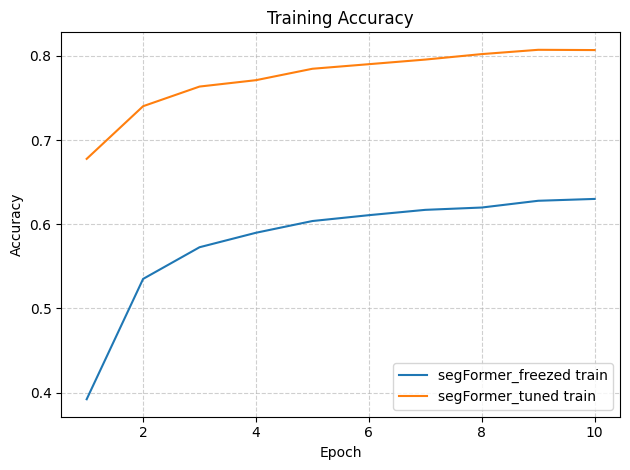

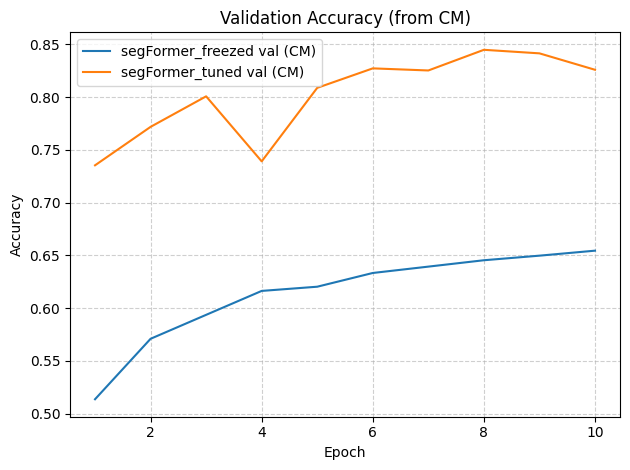

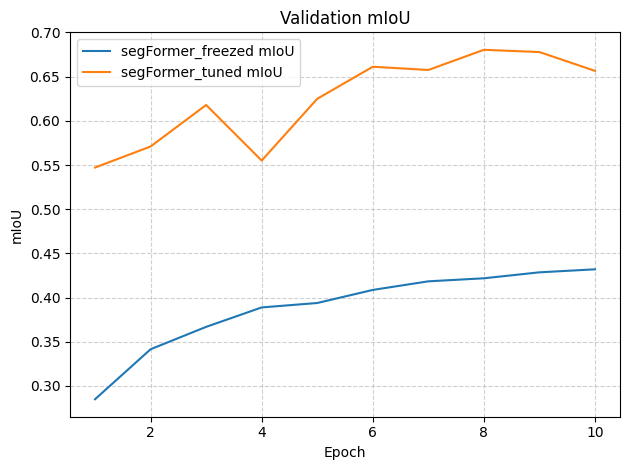

In [ ]:
ckptC_path = "segformer_5ch_6cls_frozen.ckpt"   # run with B=32/128
ckptD_path = "segFormer_tuned.ckpt"   #  run with B=4/32

ckptC = torch.load(ckptC_path, map_location="cpu")
ckptD = torch.load(ckptD_path, map_location="cpu")


cm_history_C = ckptC["cm_history"]            # list of CxC tensors
train_acc_C  = ckptC["train_accs"]             # list of per-batch train accuracies
val_mious_C  = ckptC.get("val_miou", None)   

cm_history_D = ckptD["cm_history"]
train_acc_D  = ckptD["train_accs"]
val_mious_D  = ckptD.get("val_miou", None)





# 3) Compare the two runs 
compare_two_runs(train_accs_A=train_acc_C, cm_history_A=cm_history_C,
                 train_accs_B=train_acc_D, cm_history_B=cm_history_D,
                 name_A="segFormer_freezed", name_B="segFormer_tuned",
                 val_mious_A=val_mious_C, val_mious_B=val_mious_D)



In [ ]:
import numpy as np
import pandas as pd
import torch

# F1 helpers fun tió extract the f1 scores from cm
def per_class_f1_from_cm(confusion_matrix, num_classes=6):
    f1_scores = []
 
    if torch.is_tensor(confusion_matrix):
        cm = confusion_matrix.cpu().numpy()
    else:
        cm = np.asarray(confusion_matrix)

    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision = (tp / (tp + fp)) if (tp + fp) > 0 else 0.0
        recall    = (tp / (tp + fn)) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        f1_scores.append(float(f1))

    macro_f1 = float(np.mean(f1_scores)) if len(f1_scores) > 0 else 0.0
    return f1_scores, macro_f1

def extract_f1_history(cm_history, num_classes=6):
    f1_history = []
    macro_f1_history = []
    for cm in cm_history:
        per_class_f1, macro_f1 = per_class_f1_from_cm(cm, num_classes)
        f1_history.append(per_class_f1)
        macro_f1_history.append(macro_f1)
    return f1_history, macro_f1_history

def avg_last_k(values, k=3):
    # Average over the last k values, or all if len < k
    if len(values) == 0:
        return float("nan")
    take = values[-k:] if len(values) >= k else values
    return float(np.mean(take))

# Load checkpoints
base_path             = "first_with_weights.ckpt"
own_path              = "own_model.ckpt"
deeplab_freezed_path  = "deepLab_model.ckpt"
deeplab_tuned_path    = "deepLab_tuuned_5ch_6cls.ckpt"
segformer_freezed_path= "segformer_5ch_6cls_frozen.ckpt"
segformer_tuned_path  = "segFormer_tuned.ckpt"

ckpt_base      = torch.load(base_path, map_location="cpu")
ckpt_own       = torch.load(own_path, map_location="cpu")
ckpt_dl_freeze = torch.load(deeplab_freezed_path, map_location="cpu")
ckpt_dl_tuned  = torch.load(deeplab_tuned_path, map_location="cpu")
ckpt_seg_free  = torch.load(segformer_freezed_path, map_location="cpu")
ckpt_seg_tuned = torch.load(segformer_tuned_path, map_location="cpu")

#Grab cm histories and mIoU arrays 
def get_cm_and_miou(ckpt):
    cm_hist = ckpt["cm_history"]  
    miou = ckpt.get("val_miou")
    if miou is None:
        raise KeyError("Checkpoint missing 'val_miou' or 'val_mious'.")
  
    miou = [float(x) for x in miou]
    return cm_hist, miou

num_classes = 6

base_cm_hist, base_miou                 = get_cm_and_miou(ckpt_base)
own_cm_hist, own_miou                   = get_cm_and_miou(ckpt_own)
dl_cm_hist, dl_val_miou                 = get_cm_and_miou(ckpt_dl_freeze)
dl_tuned_cm_hist, dl_tuned_val_miou     = get_cm_and_miou(ckpt_dl_tuned)
seg_cm_hist, seg_val_miou               = get_cm_and_miou(ckpt_seg_free)
seg_tuned_cm_hist, seg_tuned_val_miou   = get_cm_and_miou(ckpt_seg_tuned)

# Compute F1 histories 
w_f1_hist,   w_macro_f1_hist    = extract_f1_history(base_cm_hist, num_classes)
o_f1_hist,   o_macro_f1_hist    = extract_f1_history(own_cm_hist, num_classes)
dl_f1_hist,  dl_macro_f1_hist   = extract_f1_history(dl_cm_hist, num_classes)
dlT_f1_hist, dlT_macro_f1_hist  = extract_f1_history(dl_tuned_cm_hist, num_classes)
seg_f1_hist, seg_macro_f1_hist  = extract_f1_history(seg_cm_hist, num_classes)
segT_f1_hist, segT_macro_f1_hist= extract_f1_history(seg_tuned_cm_hist, num_classes)

# Average last 3 epochs (robust if <3 epochs)
w_avg_macro_f1    = avg_last_k(w_macro_f1_hist, 3)
o_avg_macro_f1    = avg_last_k(o_macro_f1_hist, 3)
dl_avg_macro_f1   = avg_last_k(dl_macro_f1_hist, 3)
dlT_avg_macro_f1  = avg_last_k(dlT_macro_f1_hist, 3)
seg_avg_macro_f1  = avg_last_k(seg_macro_f1_hist, 3)
segT_avg_macro_f1 = avg_last_k(segT_macro_f1_hist, 3)

w_avg_miou    = avg_last_k(base_miou, 3)
o_avg_miou    = avg_last_k(own_miou, 3)
dl_avg_miou   = avg_last_k(dl_val_miou, 3)
dlT_avg_miou  = avg_last_k(dl_tuned_val_miou, 3)
seg_avg_miou  = avg_last_k(seg_val_miou, 3)
segT_avg_miou = avg_last_k(seg_tuned_val_miou, 3)

# Build results table (6 rows, matching metrics) 
rows = [
    ("Baseline",             w_avg_macro_f1,   w_avg_miou),
    ("Deep Model",           o_avg_macro_f1,   o_avg_miou),
    ("DeepLabV3 (frozen)",   dl_avg_macro_f1,  dl_avg_miou),
    ("DeepLabV3 (tuned)",    dlT_avg_macro_f1, dlT_avg_miou),
    ("SegFormer (frozen)",   seg_avg_macro_f1, seg_avg_miou),
    ("SegFormer (tuned)",    segT_avg_macro_f1,segT_avg_miou),
]

df = pd.DataFrame(rows, columns=["Model", "Macro F1 (last-3 avg)", "mIoU (last-3 avg)"])
df["Macro F1 (last-3 avg)"] = df["Macro F1 (last-3 avg)"].map(lambda x: f"{x:.4f}" if np.isfinite(x) else "nan")
df["mIoU (last-3 avg)"]     = df["mIoU (last-3 avg)"].map(lambda x: f"{x:.4f}" if np.isfinite(x) else "nan")

print("\n" + "="*64)
print("FINAL RESULTS (Average of Last 3 Epochs)")
print("="*64)
print(df.to_string(index=False))
print("="*64)

out_path = "final_results_final.csv"
df.to_csv(out_path, index=False)
print(f"\nSaved to '{out_path}'")



FINAL RESULTS (Average of Last 3 Epochs)
             Model Macro F1 (last-3 avg) mIoU (last-3 avg)
          Baseline                0.5268            0.3724
        Deep Model                0.6010            0.4440
DeepLabV3 (frozen)                0.6258            0.4700
 DeepLabV3 (tuned)                0.7829            0.6538
SegFormer (frozen)                0.5845            0.4274
 SegFormer (tuned)                0.7975            0.6716

Saved to 'final_results_final.csv'


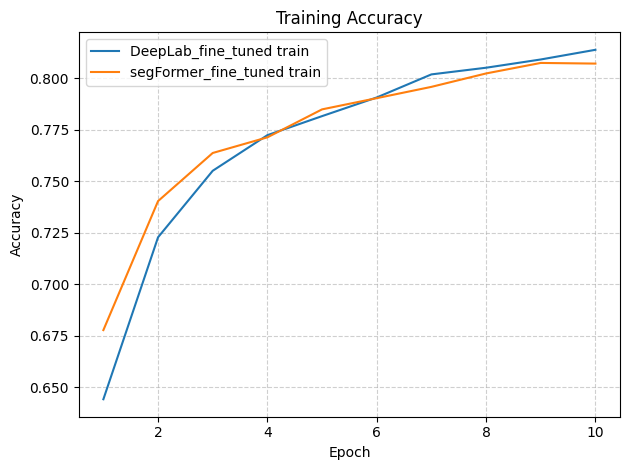

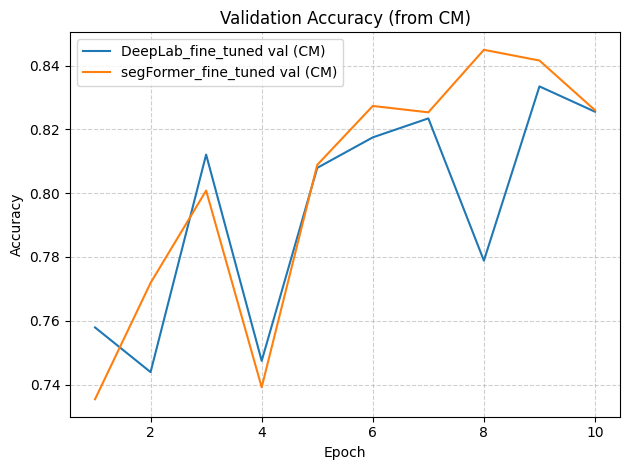

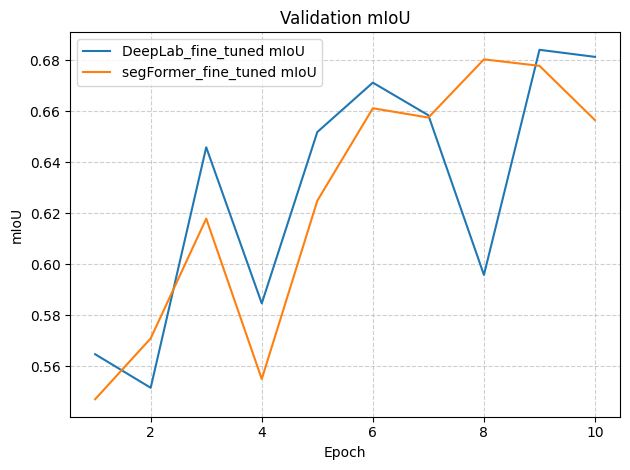

In [ ]:
ckptE_path = "deeplab_tuuned_5ch_6cls.ckpt"   # run with B=32/128
ckptF_path = "segFormer_tuned.ckpt"   #  run with B=4/32

ckptE = torch.load(ckptE_path, map_location="cpu")
ckptF = torch.load(ckptF_path, map_location="cpu")


cm_history_E = ckptE["cm_history"]            # list of CxC tensors
train_acc_E  = ckptE["train_accs"]             # list of per-batch train accuracies
val_mious_E  = ckptE.get("val_miou", None)   

cm_history_F = ckptF["cm_history"]
train_acc_F  = ckptF["train_accs"]
val_mious_F  = ckptF.get("val_miou", None)





#3) Compare the two runs (batch-size safe)
compare_two_runs(train_accs_A=train_acc_E, cm_history_A=cm_history_E,
                 train_accs_B=train_acc_F, cm_history_B=cm_history_F,
                 name_A="DeepLab_fine_tuned", name_B="segFormer_fine_tuned",
                 val_mious_A=val_mious_E, val_mious_B=val_mious_F)




PER-CLASS COMPARISON (Average of last 3 epochs)
             Class  IoU_A  IoU_B   F1_A   F1_B dIoU (B-A) dF1 (B-A)
        impervious 0.7684 0.7235 0.8690 0.8391    -0.0449   -0.0300
          building 0.8723 0.8475 0.9317 0.9172    -0.0248   -0.0145
           low_veg 0.6732 0.6376 0.8047 0.7785    -0.0356   -0.0262
              tree 0.6261 0.6471 0.7690 0.7857     0.0210    0.0168
               car 0.5425 0.6153 0.7033 0.7568     0.0727    0.0535
clutter/background 0.5472 0.4519 0.7072 0.6204    -0.0953   -0.0868
Saved per-class table to 'per_class_iou_f1_last3.csv'


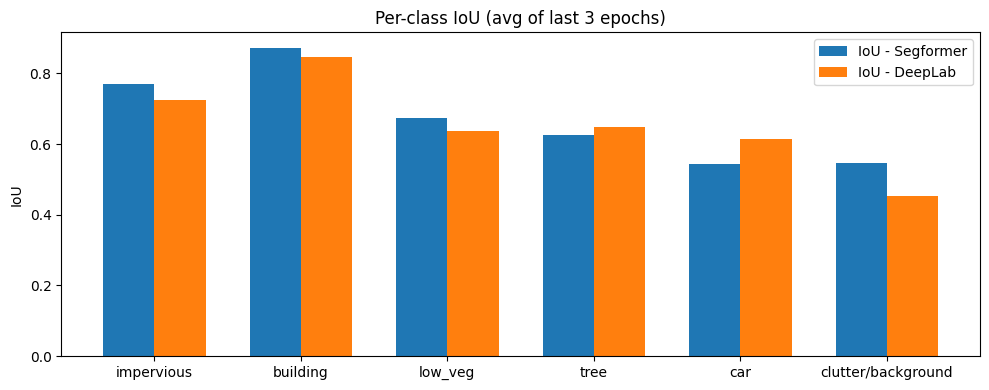

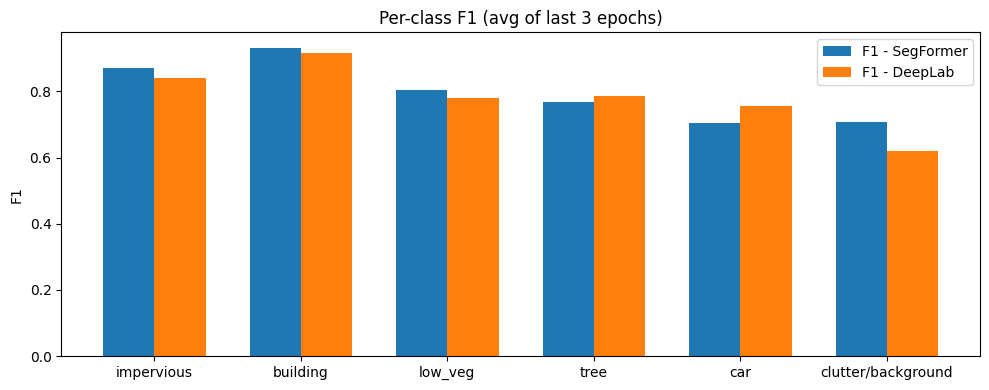

In [ ]:

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


ckptA_path = "segFormer_tuned.ckpt"        
ckptB_path = "deepLab_tuuned_5ch_6cls.ckpt" 

num_classes = 6

class_names = [f"c{i}" for i in range(num_classes)]
class_names = ["impervious", "building", "low_veg", "tree", "car", "clutter/background"]

# helpers
def avg_last_k(arr_list, k=3):
    """Average over the last k entries of a list of arrays; returns a 1D array."""
    if len(arr_list) == 0:
        return np.full((num_classes,), np.nan, dtype=float)
    take = arr_list[-k:] if len(arr_list) >= k else arr_list
    return np.nanmean(np.stack(take, axis=0), axis=0)

def per_class_iou_from_cm(cm):
    """IoU_c = TP / (TP + FP + FN) for each class c."""
    # cm: CxC (rows=GT, cols=Pred)
    if torch.is_tensor(cm):
        cm = cm.cpu().numpy()
    cm = cm.astype(np.float64)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    denom = tp + fp + fn
    iou = np.where(denom > 0, tp / denom, np.nan)
    return iou  # shape (C,)

def per_class_f1_from_cm(cm):
    #F1_c from confusion matrix: precision = TP/(TP+FP), recall = TP/(TP+FN).
    if torch.is_tensor(cm):
        cm = cm.cpu().numpy()
    cm = cm.astype(np.float64)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    prec_denom = tp + fp
    rec_denom  = tp + fn
    precision = np.where(prec_denom > 0, tp / prec_denom, 0.0)
    recall    = np.where(rec_denom  > 0, tp / rec_denom, 0.0)
    f1 = np.where((precision + recall) > 0, 2 * precision * recall / (precision + recall), 0.0)
    return f1  # shape (C,)

def histories_from_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    if "cm_history" not in ckpt:
        raise KeyError(f"{ckpt_path} has no 'cm_history'. Keys: {list(ckpt.keys())}")
    cm_hist = ckpt["cm_history"]
    # per-epoch per-class IoU and F1
    iou_hist = [per_class_iou_from_cm(cm) for cm in cm_hist]
    f1_hist  = [per_class_f1_from_cm(cm)  for cm in cm_hist]
    return np.array(iou_hist), np.array(f1_hist)  # shapes (E,C)

#compute per-class IoU and F1 histories for each run 
iou_A_hist, f1_A_hist = histories_from_ckpt(ckptA_path)
iou_B_hist, f1_B_hist = histories_from_ckpt(ckptB_path)

# last-3 averages per class 
iou_A_last3 = avg_last_k([x for x in iou_A_hist], k=3)
iou_B_last3 = avg_last_k([x for x in iou_B_hist], k=3)
f1_A_last3  = avg_last_k([x for x in f1_A_hist],  k=3)
f1_B_last3  = avg_last_k([x for x in f1_B_hist],  k=3)

# build comparison table
df = pd.DataFrame({
    "Class": class_names,
    "IoU_A": iou_A_last3,
    "IoU_B": iou_B_last3,
    "F1_A":  f1_A_last3,
    "F1_B":  f1_B_last3,
})
df["dIoU (B-A)"] = df["IoU_B"] - df["IoU_A"]
df["dF1 (B-A)"]  = df["F1_B"]  - df["F1_A"]

# pretty formatting
fmt = lambda x: "nan" if not np.isfinite(x) else f"{x:.4f}"
for col in ["IoU_A", "IoU_B", "F1_A", "F1_B", "dIoU (B-A)", "dF1 (B-A)"]:
    df[col] = df[col].map(fmt)

print("\n" + "="*66)
print("PER-CLASS COMPARISON (Average of last 3 epochs)")
print("="*66)
print(df.to_string(index=False))
print("="*66)

# Save to CSV
out_csv = "per_class_iou_f1_last3.csv"
df.to_csv(out_csv, index=False)
print(f"Saved per-class table to '{out_csv}'")

# simple bar charts ----
# Convert back to float for plotting
plot_df = pd.DataFrame({
    "Class": class_names,
    "IoU_A": iou_A_last3,
    "IoU_B": iou_B_last3,
    "F1_A":  f1_A_last3,
    "F1_B":  f1_B_last3,
})

# IoU bars
x = np.arange(len(class_names))
w = 0.35
plt.figure(figsize=(10,4))
plt.bar(x - w/2, plot_df["IoU_A"], width=w, label="IoU - Segformer")
plt.bar(x + w/2, plot_df["IoU_B"], width=w, label="IoU - DeepLab")
plt.xticks(x, class_names, rotation=0)
plt.ylabel("IoU")
plt.title("Per-class IoU (avg of last 3 epochs)")
plt.legend()
plt.tight_layout()
plt.show()

# F1 bars
plt.figure(figsize=(10,4))
plt.bar(x - w/2, plot_df["F1_A"], width=w, label="F1 - SegFormer")
plt.bar(x + w/2, plot_df["F1_B"], width=w, label="F1 - DeepLab")
plt.xticks(x, class_names, rotation=0)
plt.ylabel("F1")
plt.title("Per-class F1 (avg of last 3 epochs)")
plt.legend()
plt.tight_layout()
plt.show()


# Collecting results

In [ ]:
import torch
import numpy as np
import pandas as pd

# helper
def summarize_ckpt(path, model_name, k=3):
    # Summarize validation metrics averaged over the last k epochs.
    ckpt = torch.load(path, map_location='cpu')

    # mean of last k values for stability
    miou = float(np.mean(ckpt['val_miou'][-k:]))
    acc  = float(np.mean(ckpt['val_accs'][-k:]))

    # compute macro F1 averaged over last k confusion matrices
    f1s = []
    for cm in ckpt['cm_history'][-k:]:
        cm = cm.numpy().astype(float)
        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        fn = cm.sum(axis=1) - tp
        prec = np.where(tp + fp > 0, tp / (tp + fp), 0)
        rec  = np.where(tp + fn > 0, tp / (tp + fn), 0)
        f1   = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0)
        f1s.append(np.nanmean(f1))
    macro_f1 = float(np.mean(f1s))

    return dict(Model=model_name, Val_mIoU=miou, Val_Acc=acc, MacroF1=macro_f1)


# gather all models
paths = {
    "DoubleConv": "./first_with_weights.ckpt",
    "PotsdamSegNet": "./own_model.ckpt",
    "DeepLabV3 (frozen)": "./deepLab_model.ckpt",
    "DeepLabV3 (fine-tuned)": "./deeplab_tuuned_5ch_6cls.ckpt",
    "SegFormer-B0 (frozen)": "./segformer_5ch_6cls_frozen.ckpt",
    "SegFormer-B0 (fine-tuned)": "./segFormer_tuned.ckpt",
}

records = [summarize_ckpt(p, name, k=3) for name, p in paths.items()]
df = pd.DataFrame(records)
print(df.round(4))
df.to_csv("overall_metrics_last3.csv", index=False)


                       Model  Val_mIoU  Val_Acc  MacroF1
0                 DoubleConv    0.3724   0.5887   0.5268
1              PotsdamSegNet    0.4440   0.6635   0.6010
2         DeepLabV3 (frozen)    0.4700   0.6833   0.6258
3     DeepLabV3 (fine-tuned)    0.6538   0.8125   0.7829
4      SegFormer-B0 (frozen)    0.4274   0.6495   0.5845
5  SegFormer-B0 (fine-tuned)    0.6716   0.8374   0.7975


In [ ]:
def extract_perclass_metrics(ckpt_path, model_name, k=3):
    # Extract per-class IoU and F1 averaged over last k confusion matrices.
    ckpt = torch.load(ckpt_path, map_location='cpu')
    cm_hist = ckpt["cm_history"]

    ious, f1s = [], []
    for cm in cm_hist[-k:]:
        cm = cm.numpy().astype(float)
        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        fn = cm.sum(axis=1) - tp
        iou = tp / (tp + fp + fn + 1e-9)
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        ious.append(iou)
        f1s.append(f1)

    iou_avg = np.mean(ious, axis=0)
    f1_avg  = np.mean(f1s, axis=0)

    return pd.DataFrame({
        "Model": model_name,
        "Class": ["impervious", "building", "low_veg", "tree", "car", "clutter/background"],
        "IoU": iou_avg,
        "F1":  f1_avg,
    })


# Collect for all models
all_dfs = [extract_perclass_metrics(path, name, k=3) for name, path in paths.items()]
per_class_df = pd.concat(all_dfs)
print(per_class_df.round(4))
per_class_df.to_csv("per_class_metrics_last3.csv", index=False)


                       Model               Class     IoU      F1
0                 DoubleConv          impervious  0.4764  0.6415
1                 DoubleConv            building  0.5307  0.6904
2                 DoubleConv             low_veg  0.4825  0.6508
3                 DoubleConv                tree  0.3321  0.4982
4                 DoubleConv                 car  0.1922  0.3217
5                 DoubleConv  clutter/background  0.2207  0.3584
0              PotsdamSegNet          impervious  0.5743  0.7294
1              PotsdamSegNet            building  0.6578  0.7935
2              PotsdamSegNet             low_veg  0.4418  0.6125
3              PotsdamSegNet                tree  0.4317  0.6030
4              PotsdamSegNet                 car  0.2250  0.3674
5              PotsdamSegNet  clutter/background  0.3335  0.5001
0         DeepLabV3 (frozen)          impervious  0.4982  0.6648
1         DeepLabV3 (frozen)            building  0.7174  0.8354
2         DeepLabV3 (froz

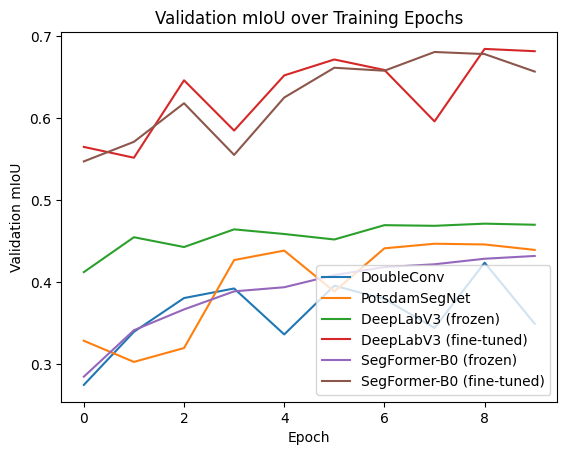

In [9]:
import matplotlib.pyplot as plt
for name, path in paths.items():
    ckpt = torch.load(path, map_location='cpu')
    plt.plot(ckpt['val_miou'], label=name)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Validation mIoU')
plt.title('Validation mIoU over Training Epochs')
plt.show()


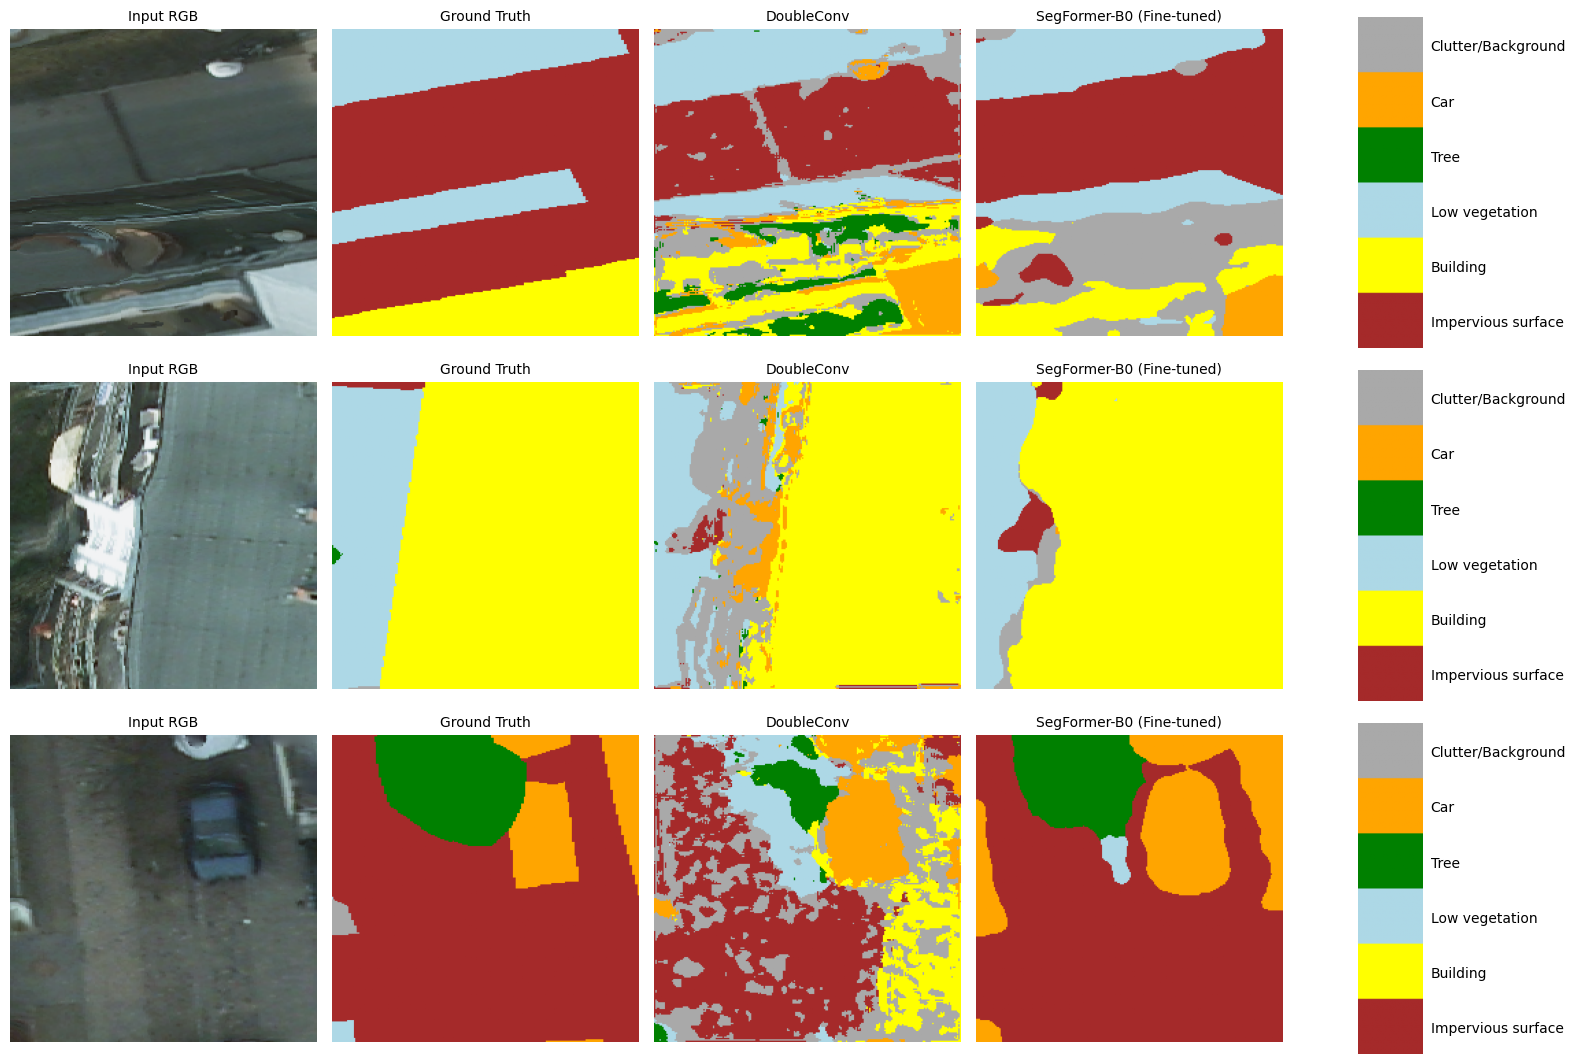

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from transformers import SegformerForSemanticSegmentation


class_labels = {
    0: ('Impervious surface', '#A52A2A'),  # Brown
    1: ('Building',            '#FFFF00'),  # Yellow
    2: ('Low vegetation',      '#ADD8E6'),  # Light Blue
    3: ('Tree',                '#008000'),  # Green
    4: ('Car',                 '#FFA500'),  # Orange
    5: ('Clutter/Background',  '#A9A9A9')   # Gray
}
# [C,3] array in 0..1
colors = np.array(
    [tuple(int(v[i:i+2], 16) for i in (1, 3, 5)) for _, v in class_labels.values()]
) / 255.0

# b´the baseline model
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, out_channels, 3, padding=1)
        )
    def forward(self, x):
        return self.conv(x)

# SEGFORMER (5-ch fine-tune builder)
NUM_CLASSES = 6
IN_CHANNELS = 5
MODEL_NAME = "nvidia/segformer-b0-finetuned-ade-512-512"

def build_segformer5ch_finetune(model_name=MODEL_NAME, num_classes=NUM_CLASSES, in_channels=IN_CHANNELS):
    model = SegformerForSemanticSegmentation.from_pretrained(model_name)

    
    model.config.num_labels = num_classes
    model.config.id2label = {i: f"class_{i}" for i in range(num_classes)}
    model.config.label2id = {v: k for k, v in model.config.id2label.items()}

   
    in_ch = model.decode_head.classifier.in_channels
    model.decode_head.classifier = nn.Conv2d(in_ch, num_classes, kernel_size=1)
    if hasattr(model, "auxiliary_head") and (model.auxiliary_head is not None):
        aux_in = model.auxiliary_head.classifier.in_channels
        model.auxiliary_head.classifier = nn.Conv2d(aux_in, num_classes, kernel_size=1)

    # first patch embedding: 5 channels (RGB, IR, DSM)
    old_proj = model.segformer.encoder.patch_embeddings[0].proj
    new_proj = nn.Conv2d(
        in_channels,
        old_proj.out_channels,
        kernel_size=old_proj.kernel_size,
        stride=old_proj.stride,
        padding=old_proj.padding,
        bias=(old_proj.bias is not None),
    )
    with torch.no_grad():
        # copy pretrained RGB
        new_proj.weight[:, :3] = old_proj.weight
        # IR = mean(RGB)
        mean_rgb = old_proj.weight.mean(dim=1, keepdim=True)
        new_proj.weight[:, 3:4] = mean_rgb
        # DSM = zeros (your chosen init)
        new_proj.weight[:, 4:5] = 0.0
        if old_proj.bias is not None and new_proj.bias is not None:
            new_proj.bias.copy_(old_proj.bias)
    model.segformer.encoder.patch_embeddings[0].proj = new_proj

    # unfreeze everything
    for p in model.parameters():
        p.requires_grad = True

    # wrapper to return (B,C,H,W)
    class SegformerWrapper(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            out = self.m(pixel_values=x)      # HF expects pixel_values
            logits = out.logits               # (B,C,h,w)
            logits = F.interpolate(
                logits, size=(x.shape[2], x.shape[3]),
                mode="bilinear", align_corners=False
            )
            return logits

    return SegformerWrapper(model)

# LOAD MODELS 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_double = DoubleConv(in_channels=5, out_channels=6).to(device)
model_segformer = build_segformer5ch_finetune().to(device)

double_ckpt = torch.load("first_with_weights.ckpt", map_location="cpu")
seg_ckpt    = torch.load("segFormer_tuned.ckpt", map_location="cpu")

model_double.load_state_dict(double_ckpt["model_state_dict"])
model_segformer.load_state_dict(seg_ckpt["model_state_dict"])
model_double.eval()
model_segformer.eval()

# GET A SMALL BATCH 
# using the test loader
if 'test_loader' in globals():
    batch = next(iter(test_loader))
elif 'val_loader' in globals():
    batch = next(iter(val_loader))
else:
    raise RuntimeError("Define val_loader or test_loader before running this script.")

x, y = batch
n_show = min(3, x.shape[0])
x, y = x[:n_show].to(device), y[:n_show].to(device)

# INFERENCE 
with torch.no_grad():
    preds_double = torch.argmax(model_double(x), dim=1)
    preds_segformer = torch.argmax(model_segformer(x), dim=1)

#  MASK -> RGB 
def decode_mask(mask_np):
    h, w = mask_np.shape
    rgb = np.zeros((h, w, 3), dtype=np.float32)
    for c, color in enumerate(colors):
        rgb[mask_np == c] = color
    return rgb

#  STACKED VERTICAL PALETTE 
def draw_palette_stack(ax, reverse_order=True):
    # 
    # Draws a vertical stacked color bar with class names as ticks on the RIGHT.
    # 
    idxs = list(class_labels.keys())
    if reverse_order:
        idxs = idxs[::-1]

    stripe_h = 30   # pixels per class stripe 
    stripe_w = 35   # bar thickness in pixels
    stack = []
    for i in idxs:
        rgb = (np.array([int(class_labels[i][1][j:j+2], 16) for j in (1,3,5)]) / 255.0)
        block = np.tile(rgb[None, None, :], (stripe_h, stripe_w, 1))
        stack.append(block)
    stack = np.vstack(stack)  # (H, W, 3)

    ax.imshow(stack, origin="upper")
    ax.set_xticks([])

    centers = np.arange(stripe_h/2, stack.shape[0], stripe_h)
    ax.set_yticks(centers)
    ax.set_yticklabels([class_labels[i][0] for i in idxs], fontsize=10)

    ax.yaxis.tick_right()                 # labels on right
    ax.tick_params(axis='y', length=0, pad=6)
    for sp in ax.spines.values():         # no spines
        sp.set_visible(False)


fig, axes = plt.subplots(
    n_show, 5, figsize=(16, 3.6 * n_show),
    gridspec_kw={"width_ratios": [1, 1, 1, 1, 0.6]}
)
if n_show == 1:
    axes = np.expand_dims(axes, 0)

for i in range(n_show):
    rgb = x[i, :3].detach().cpu().permute(1, 2, 0).numpy()
    gt  = decode_mask(y[i].detach().cpu().numpy())
    p1  = decode_mask(preds_double[i].detach().cpu().numpy())
    p2  = decode_mask(preds_segformer[i].detach().cpu().numpy())

    panels = [rgb, gt, p1, p2]
    titles = ["Input RGB", "Ground Truth", "DoubleConv", "SegFormer-B0 (Fine-tuned)"]

    for j in range(4):
        ax = axes[i, j]
        ax.imshow(panels[j])
        ax.set_title(titles[j], fontsize=10)
        ax.axis("off")

    # rightmost column: stacked palette bar
    draw_palette_stack(axes[i, 4], reverse_order=True)

plt.tight_layout()
plt.savefig("qualitative_results.png", dpi=300)
plt.show()


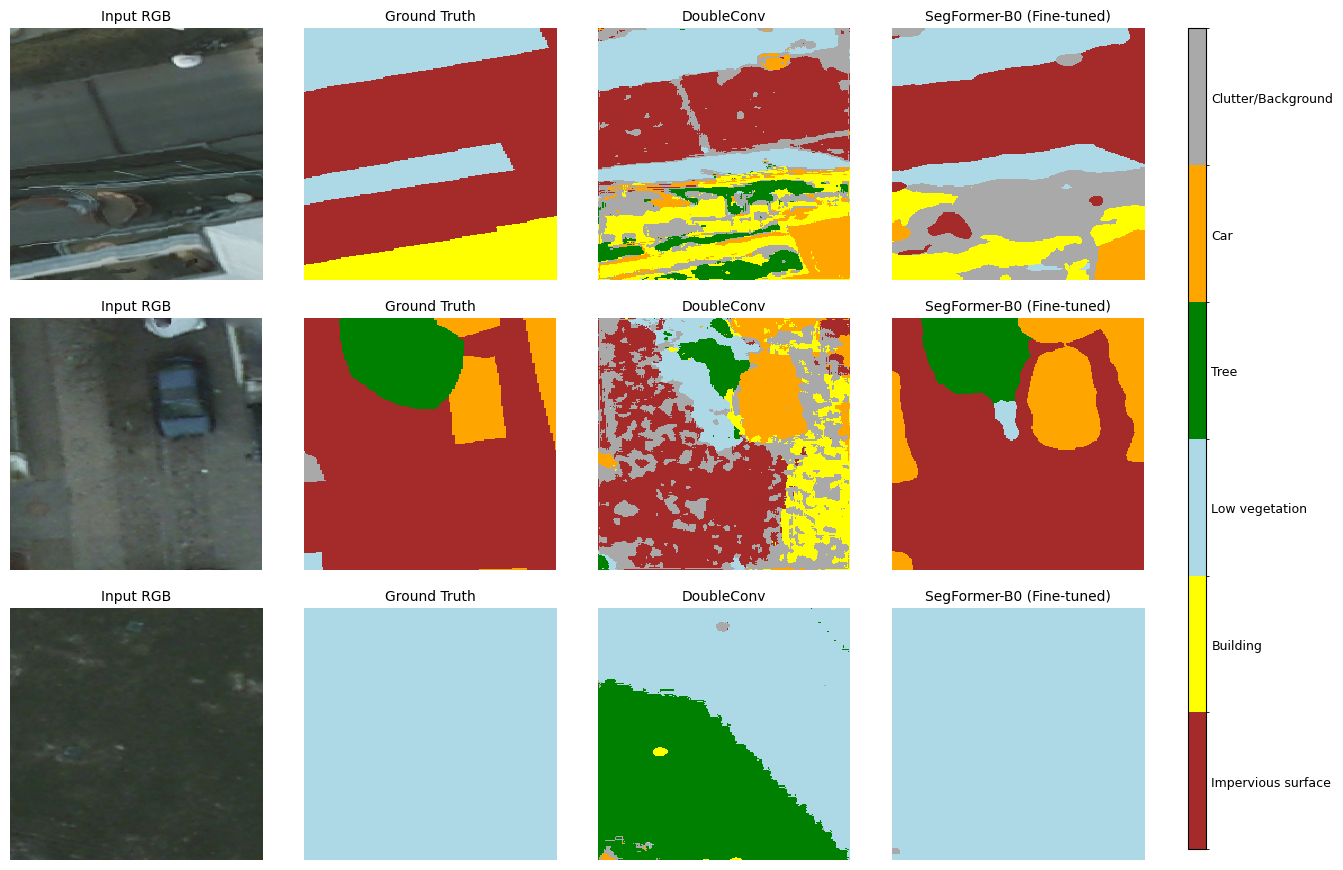

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import SegformerForSemanticSegmentation

# Class map / colors
class_labels = {
    0: ('Impervious surface', '#A52A2A'),  # Brown
    1: ('Building',            '#FFFF00'),  # Yellow
    2: ('Low vegetation',      '#ADD8E6'),  # Light Blue
    3: ('Tree',                '#008000'),  # Green
    4: ('Car',                 '#FFA500'),  # Orange
    5: ('Clutter/Background',  '#A9A9A9'),  # Gray
}
class_names  = [v[0] for _, v in class_labels.items()]
class_hex    = [v[1] for _, v in class_labels.items()]
cmap_listed  = mcolors.ListedColormap(class_hex)
norm         = mcolors.BoundaryNorm(boundaries=np.arange(len(class_labels)+1)-0.5,
                                    ncolors=len(class_labels))

#  Models 
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, out_channels, 3, padding=1)
        )
    def forward(self, x):
        return self.conv(x)

NUM_CLASSES = 6
IN_CHANNELS = 5
MODEL_NAME  = "nvidia/segformer-b0-finetuned-ade-512-512"

def build_segformer5ch_finetune(model_name=MODEL_NAME, num_classes=NUM_CLASSES, in_channels=IN_CHANNELS):
    m = SegformerForSemanticSegmentation.from_pretrained(model_name)

    # heads to our num classes
    m.config.num_labels = num_classes
    m.config.id2label = {i: f"class_{i}" for i in range(num_classes)}
    m.config.label2id = {v: k for k, v in m.config.id2label.items()}

    in_ch = m.decode_head.classifier.in_channels
    m.decode_head.classifier = nn.Conv2d(in_ch, num_classes, kernel_size=1)

    if hasattr(m, "auxiliary_head") and (m.auxiliary_head is not None):
        aux_in = m.auxiliary_head.classifier.in_channels
        m.auxiliary_head.classifier = nn.Conv2d(aux_in, num_classes, kernel_size=1)

    # first patch embedding to 5 channels
    old_proj = m.segformer.encoder.patch_embeddings[0].proj
    new_proj = nn.Conv2d(
        in_channels, old_proj.out_channels,
        kernel_size=old_proj.kernel_size,
        stride=old_proj.stride,
        padding=old_proj.padding,
        bias=(old_proj.bias is not None),
    )
    with torch.no_grad():
        # copy RGB kernels
        new_proj.weight[:, :3] = old_proj.weight
        # IR as mean of RGB
        mean_rgb = old_proj.weight.mean(dim=1, keepdim=True)
        new_proj.weight[:, 3:4] = mean_rgb
        # DSM zeros 
        new_proj.weight[:, 4:5] = 0.0
        if old_proj.bias is not None and new_proj.bias is not None:
            new_proj.bias.copy_(old_proj.bias)
    m.segformer.encoder.patch_embeddings[0].proj = new_proj

    # unfreeze all
    for p in m.parameters():
        p.requires_grad = True

    class Wrapper(nn.Module):
        def __init__(self, mm):
            super().__init__()
            self.m = mm
        def forward(self, x):
            out = self.m(pixel_values=x)
            logits = out.logits
            return F.interpolate(logits, size=(x.shape[2], x.shape[3]),
                                 mode="bilinear", align_corners=False)

    return Wrapper(m)

#  Load checkpoints 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_double    = DoubleConv(in_channels=5, out_channels=6).to(device)
model_segformer = build_segformer5ch_finetune().to(device)

double_ckpt = torch.load("first_with_weights.ckpt", map_location="cpu")
seg_ckpt    = torch.load("segFormer_tuned.ckpt", map_location="cpu")

model_double.load_state_dict(double_ckpt["model_state_dict"])
model_segformer.load_state_dict(seg_ckpt["model_state_dict"])
model_double.eval()
model_segformer.eval()

#  Batch (uses test_loader, else val_loader) 
batch = next(iter(test_loader))
x, y = batch
#n_show = min(3, x.shape[0])
indices = [0, 2, 7]  # example
x = x[indices]
y = y[indices]

x = x.to(device)
y = y.to(device)

with torch.no_grad():
    pred_double    = torch.argmax(model_double(x), dim=1)
    pred_segformer = torch.argmax(model_segformer(x), dim=1)

# Plot helper 
def show_mask(ax, mask, title):
    """mask: (H,W) int, rendered with discrete cmap/norm"""
    im = ax.imshow(mask, cmap=cmap_listed, norm=norm, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    return im

#  Figure: 4 columns + THIN COLORBAR 
fig, axes = plt.subplots(
    n_show, 4, figsize=(15, 3.6 * n_show),
    gridspec_kw={"wspace": 0.05, "hspace": 0.15}
)

if n_show == 1:
    axes = np.expand_dims(axes, 0)

mappable_for_cbar = None

for i in range(n_show):
    # RGB only
    rgb = x[i, :3].detach().cpu().permute(1, 2, 0).numpy()
    axes[i, 0].imshow(np.clip(rgb, 0, 1))
    axes[i, 0].set_title("Input RGB", fontsize=10)
    axes[i, 0].axis("off")

    # GT and predictions (use same cmap/norm)
    im_gt  = show_mask(axes[i, 1], y[i].detach().cpu().numpy(), "Ground Truth")
    im_dcv = show_mask(axes[i, 2], pred_double[i].detach().cpu().numpy(), "DoubleConv")
    im_sfg = show_mask(axes[i, 3], pred_segformer[i].detach().cpu().numpy(), "SegFormer-B0 (Fine-tuned)")

    # Keep a handle for the colorbar
    mappable_for_cbar = im_gt


cax = fig.add_axes([0.92, 0.12, 0.012, 0.76]) 
cbar = fig.colorbar(mappable_for_cbar, cax=cax, ticks=np.arange(len(class_labels)))

cbar.ax.set_yticklabels(class_names, fontsize=9)
cbar.ax.tick_params(length=0) 

plt.savefig("qualitative_results.png", dpi=300, bbox_inches="tight")
plt.show()
